# Transición de Cobertura del Suelo vs. Condición Socioeconómica (2018‑2021)

Este notebook cruza los 21 municipios de Cundinamarca encuestados en 2021 con sus matrices de transición de cobertura del suelo 2018→2021, generando diagramas de dispersión 2D y estadísticos de asociación.


In [9]:
import warnings
from pathlib import Path
import sys
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name == 'src' else cwd
DATA_DIR = root / 'data'
TRANSITIONS_DIR = DATA_DIR / 'transitions'
MULTI_DIR = DATA_DIR / 'multiproposito'

sys.path.append(str(root / 'src'))
from soil_poverty_analysis import (
    find_repo_root,
    parse_weight_series,
    normalize_municipality,
)

root = find_repo_root(root)

## 4.1 Preparación de los Datos Socioeconómicos (Eje Y)

Reconstruimos el dataset municipal exactamente como en `src/03_recreate_municipality_level_analysis.ipynb`, utilizando las funciones auxiliares de `soil_poverty_analysis` y replicando la lógica de carga, unión y cálculo de tasas ponderadas. **No se guarda ningún CSV intermedio**; el DataFrame queda en memoria.


In [10]:
manual_mapping = {
    'bojaca': 'Bojacá',
    'cajica': 'Cajicá',
    'chia': 'Chía',
    'facatativa': 'Facatativá',
    'fusagasuga': 'Fusagasugá',
    'gachancipa': 'Gachancipá',
    'sibate': 'Sibaté',
    'sopo': 'Sopó',
    'tocancipa': 'Tocancipá',
    'zipacon': 'Zipacón',
    'zipaquira': 'Zipaquirá',
    'rosal': 'el rosal',
    'calera': 'la calera',
}

def load_semicolon_csv(path, columns=None, encodings=('utf-8', 'latin1')):
    last_error = None
    for encoding in encodings:
        try:
            if columns is None:
                return pd.read_csv(path, sep=';', encoding=encoding)
            return pd.read_csv(path, sep=';', encoding=encoding, usecols=list(columns))
        except Exception as exc:
            last_error = exc
    raise last_error

ident = load_semicolon_csv(
    MULTI_DIR / 'Identificación (Capítulo A).csv',
    columns=['DIRECTORIO', 'DPTO', 'MPIO', 'NOMBRE_ESTRATO', 'FEX_C'],
    encodings=('latin1', 'utf-8'),
)
ident['weight'] = parse_weight_series(ident['FEX_C'])
ident_cund = ident[ident['DPTO'] == 25].copy()

households_c = load_semicolon_csv(
    MULTI_DIR / 'Condiciones habitacionales del hogar (Capítulo C).csv',
    columns=['DIRECTORIO', 'DIRECTORIO_HOG', 'NHCCP1', 'NHCCP31', 'NHCCP37', 'FEX_C'],
)
households_d = load_semicolon_csv(
    MULTI_DIR / 'Servicios públicos domiciliarios y de TIC (Capítulo D).csv',
    columns=['DIRECTORIO', 'DIRECTORIO_HOG', 'NHCDP1', 'NHCDP3', 'NHCDP9', 'NHCDP15', 'NHCDP28', 'FEX_C'],
)
households_l = load_semicolon_csv(
    MULTI_DIR / 'Percepción sobre las condiciones de vida y el desempeño institucional (Capítulo L).csv',
    columns=['DIRECTORIO', 'DIRECTORIO_HOG', 'NHCLP10', 'NHCLP11', 'NHCLP14', 'NHCLP16', 'NHCLP17', 'NHCLP18', 'NHCLP19', 'FEX_C'],
)
for df in [households_c, households_d, households_l]:
    df['weight'] = parse_weight_series(df['FEX_C'])

people_e = load_semicolon_csv(
    MULTI_DIR / 'Composición del hogar y demografía (Capítulo E).csv',
    columns=['DIRECTORIO', 'DIRECTORIO_HOG', 'DIRECTORIO_PER', 'SEXO', 'FEX_C'],
)
people_h = load_semicolon_csv(
    MULTI_DIR / 'Educaciвn (Capitulo H).csv',
    columns=['DIRECTORIO', 'DIRECTORIO_HOG', 'DIRECTORIO_PER', 'NPCHP24', 'NPCHP36', 'FEX_C'],
)
people_k = load_semicolon_csv(
    MULTI_DIR / 'Fuerza de trabajo (Capítulo K).csv',
    columns=['DIRECTORIO', 'DIRECTORIO_HOG', 'DIRECTORIO_PER', 'PET', 'OCU', 'DES', 'FL', 'OINFORMAL', 'FEX_C'],
)
for df in [people_e, people_h, people_k]:
    df['weight'] = parse_weight_series(df['FEX_C'])

ident_unique = ident_cund[['NOMBRE_ESTRATO']].drop_duplicates().copy()
ident_unique['municipio_base'] = ident_unique['NOMBRE_ESTRATO'].apply(normalize_municipality)
ident_unique['municipio_base'] = ident_unique['municipio_base'].map(lambda x: manual_mapping.get(x, x))
ident_unique['municipio_base_key'] = ident_unique['municipio_base'].apply(normalize_municipality)

base_households = ident_cund[['DIRECTORIO', 'NOMBRE_ESTRATO']].copy()
households_c = households_c.merge(base_households, on='DIRECTORIO', how='inner')
households_d = households_d.merge(base_households, on='DIRECTORIO', how='inner')
households_l = households_l.merge(base_households, on='DIRECTORIO', how='inner')

households_d = households_d.rename(columns={'weight': 'weight_d'})
households_l = households_l.rename(columns={'weight': 'weight_l'})

households = households_c.merge(
    households_d[['DIRECTORIO', 'DIRECTORIO_HOG', 'NHCDP1', 'NHCDP3', 'NHCDP9', 'NHCDP15', 'NHCDP28', 'NOMBRE_ESTRATO', 'weight_d']],
    on=['DIRECTORIO', 'DIRECTORIO_HOG', 'NOMBRE_ESTRATO'],
    how='left',
)
households = households.merge(
    households_l[['DIRECTORIO', 'DIRECTORIO_HOG', 'NHCLP10', 'NHCLP11', 'NHCLP14', 'NHCLP16', 'NHCLP17', 'NHCLP18', 'NHCLP19', 'NOMBRE_ESTRATO', 'weight_l']],
    on=['DIRECTORIO', 'DIRECTORIO_HOG', 'NOMBRE_ESTRATO'],
    how='left',
)
households['weight'] = households['weight'].fillna(households['weight_d']).fillna(households['weight_l'])
households = households.drop(columns=['weight_d', 'weight_l'])

households['poor_subjective'] = (households['NHCLP11'] == 1).astype(float)
households['income_insufficient'] = (households['NHCLP10'] == 1).astype(float)
households['food_insecurity_any'] = households[['NHCLP16', 'NHCLP17', 'NHCLP18', 'NHCLP19']].eq(1).any(axis=1).astype(float)
households['tenure_own'] = (households['NHCCP1'] == 1).astype(float)
households['sanitation_access'] = (households['NHCCP31'] == 1).astype(float)
households['garbage_access'] = (households['NHCCP37'] == 1).astype(float)
households['water_access'] = (households['NHCDP1'] == 1).astype(float)
households['sewer_access'] = (households['NHCDP3'] == 1).astype(float)
households['electricity_access'] = (households['NHCDP9'] == 1).astype(float)
households['internet_access'] = (households['NHCDP28'] == 1).astype(float)

def weighted_mean(series, weights):
    s = pd.to_numeric(series, errors='coerce')
    w = pd.to_numeric(weights, errors='coerce').fillna(0)
    total_w = w.sum()
    return np.average(s, weights=w) if total_w > 0 else np.nan

household_summary = []
for municipality, group in households.groupby('NOMBRE_ESTRATO'):
    row = {
        'NOMBRE_ESTRATO': municipality,
        'n_households': group['DIRECTORIO_HOG'].nunique(),
        'weighted_households': group['weight'].sum(),
    }
    for col in ['poor_subjective', 'income_insufficient', 'food_insecurity_any', 'tenure_own', 'sanitation_access', 'garbage_access', 'water_access', 'sewer_access', 'electricity_access', 'internet_access']:
        row[col + '_rate'] = weighted_mean(group[col], group['weight'])
    household_summary.append(row)

household_summary = pd.DataFrame(household_summary)
household_summary['municipio_base'] = household_summary['NOMBRE_ESTRATO'].apply(normalize_municipality)
household_summary['municipio_base'] = household_summary['municipio_base'].map(lambda x: manual_mapping.get(x, x))

people_e = people_e.merge(ident_cund[['DIRECTORIO', 'NOMBRE_ESTRATO']], on='DIRECTORIO', how='inner')
people_h = people_h.merge(ident_cund[['DIRECTORIO', 'NOMBRE_ESTRATO']], on='DIRECTORIO', how='inner')
people_k = people_k.merge(ident_cund[['DIRECTORIO', 'NOMBRE_ESTRATO']], on='DIRECTORIO', how='inner')

people_e['female'] = (people_e['SEXO'] == 2).astype(float)
people_h['scholarship'] = (people_h['NPCHP24'] == 1).astype(float)
people_h['online_courses'] = (people_h['NPCHP36'] == 1).astype(float)
people_k['pet'] = (people_k['PET'] == 1).astype(float)
people_k['ocu'] = (people_k['OCU'] == 1).astype(float)
people_k['des'] = (people_k['DES'] == 1).astype(float)
people_k['fl'] = (people_k['FL'] == 1).astype(float)
people_k['informal'] = (people_k['OINFORMAL'] == 1).astype(float)

person_summary = []
for name, df, indicator in [
    ('female', people_e, 'female'),
    ('scholarship', people_h, 'scholarship'),
    ('online_courses', people_h, 'online_courses'),
    ('pet', people_k, 'pet'),
    ('ocu', people_k, 'ocu'),
    ('des', people_k, 'des'),
    ('fl', people_k, 'fl'),
    ('informal', people_k, 'informal'),
]:
    rows = []
    for municipality, group in df.groupby('NOMBRE_ESTRATO'):
        rows.append({
            'NOMBRE_ESTRATO': municipality,
            'n_people': group['DIRECTORIO_PER'].nunique(),
            'weighted_people': group['weight'].sum(),
            f'{name}_rate': weighted_mean(group[indicator], group['weight']),
        })
    person_summary.append(pd.DataFrame(rows))

person_summary_df = person_summary[0]
for frame in person_summary[1:]:
    person_summary_df = person_summary_df.merge(frame, on=['NOMBRE_ESTRATO', 'n_people', 'weighted_people'], how='outer')

household_summary = household_summary.rename(columns={'municipio_base': 'municipio_base_hh'})
municipality_df = ident_unique[['NOMBRE_ESTRATO', 'municipio_base']].merge(household_summary, on='NOMBRE_ESTRATO', how='left')
municipality_df = municipality_df.merge(person_summary_df, on='NOMBRE_ESTRATO', how='left')

municipality_df = municipality_df[municipality_df['municipio_base'].notna()].copy()

def aggregate_by_municipality(df):
    group_cols = ['municipio_base']
    count_cols = ['n_households', 'weighted_households', 'n_people', 'weighted_people']
    rate_cols = [c for c in df.columns if c.endswith('_rate') and c not in count_cols]
    constant_cols = [c for c in df.columns if c not in group_cols + count_cols + rate_cols + ['NOMBRE_ESTRATO', 'municipio_base_key']]
    out = []
    for municipality, group in df.groupby(group_cols, dropna=False):
        municipality_value = municipality[0] if isinstance(municipality, tuple) else municipality
        row = {'municipio_base': municipality_value}
        for c in count_cols:
            row[c] = group[c].sum() if c in group.columns else np.nan
        for c in rate_cols:
            if 'weighted_households' in group.columns and c.startswith(('poor_', 'income_', 'food_', 'tenure_', 'sanitation_', 'garbage_', 'water_', 'sewer_', 'electricity_', 'internet_')):
                weights = group['weighted_households']
            elif 'weighted_people' in group.columns and c.endswith('_rate'):
                weights = group['weighted_people']
            else:
                weights = pd.Series(1, index=group.index)
            row[c] = weighted_mean(group[c], weights)
        for c in constant_cols:
            row[c] = group[c].iloc[0] if c in group.columns else np.nan
        out.append(row)
    return pd.DataFrame(out)

municipality_df = aggregate_by_municipality(municipality_df)
municipality_df = municipality_df.sort_values('municipio_base').reset_index(drop=True)

print('Rows in municipality_df:', len(municipality_df))
assert len(municipality_df) == 21
municipality_df[['municipio_base', 'poor_subjective_rate', 'income_insufficient_rate']].head()

Rows in municipality_df: 21


,municipio_base,poor_subjective_rate,income_insufficient_rate
0,Bojacá,0.326021,0.312127
1,Cajicá,0.141558,0.145110
2,Chía,0.249899,0.194012
3,Facatativá,0.370756,0.293271
4,Fusagasugá,0.315716,0.261989


## 4.2 Preparación de los Datos de Transición (Eje X)

Leemos los archivos de transición de `data/transitions/`, derivamos el `municipio_base` del nombre de archivo y descartamos `Anolaima` (sin datos de encuesta). Cada CSV se carga como una matriz de transición con columnas `from_class`, `to_class` y `area_ha`.


In [11]:
transition_files = sorted(TRANSITIONS_DIR.glob('Transition_*_2018-2021.csv'))
print('Archivos de transición encontrados:', len(transition_files))

records = []
for path in transition_files:
    raw_name = path.name.replace('Transition_', '').replace('_2018-2021.csv', '')
    normalized = normalize_municipality(raw_name)
    mapped = manual_mapping.get(normalized, normalized)
    records.append({'file': str(path), 'raw': raw_name, 'normalized': normalized, 'municipio_base': mapped})

file_map = pd.DataFrame(records)
file_map = file_map[file_map['municipio_base'].str.lower() != 'anolaima'].reset_index(drop=True)
print('Municipios con datos de transición (sin Anolaima):', len(file_map))
file_map[['raw', 'normalized', 'municipio_base']].head()

Archivos de transición encontrados: 22
Municipios con datos de transición (sin Anolaima): 21


,raw,normalized,municipio_base
0,Bojaca,bojaca,Bojacá
1,Cajica,cajica,Cajicá
2,Calera,calera,la calera
3,Chia,chia,Chía
4,Cota,cota,cota


In [12]:
def load_transition(path):
    df = pd.read_csv(path, sep=',')
    df.columns = ['from_class', 'to_class', 'area_ha']
    df['area_ha'] = pd.to_numeric(df['area_ha'], errors='coerce')
    return df

def compute_transition_indices(path, municipio_base):
    df = load_transition(path)
    total = df['area_ha'].sum()
    f = df.set_index(['from_class', 'to_class'])['area_ha'].to_dict()
    get = lambda a, b: f.get((a, b), 0.0)
    F_ForAgro = get('Forest formation', 'Agricultural and livestock area')
    F_WatAgro = get('Water body', 'Agricultural and livestock area')
    F_AgroFor = get('Agricultural and livestock area', 'Forest formation')
    F_AgroWat = get('Agricultural and livestock area', 'Water body')
    F_ForFor = get('Forest formation', 'Forest formation')
    F_WatWat = get('Water body', 'Water body')
    F_AgroAgro = get('Agricultural and livestock area', 'Agricultural and livestock area')
    A_total = total
    degrad_total = (F_ForAgro + F_WatAgro) / A_total * 100 if A_total else np.nan
    recover_total = (F_AgroFor + F_AgroWat) / A_total * 100 if A_total else np.nan
    degrad_forest_rel = F_ForAgro / F_ForFor if F_ForFor else np.nan
    degrad_water_rel = F_WatAgro / F_WatWat if F_WatWat else np.nan
    recover_agro_rel = F_AgroFor / F_AgroAgro if F_AgroAgro else np.nan
    ind_neto_transicion = degrad_total - recover_total
    ind_neto_transicion_rel = (degrad_forest_rel + degrad_water_rel) - recover_agro_rel
    return {
        'municipio_base': municipio_base,
        'A_total': A_total,
        'F_ForAgro': F_ForAgro,
        'F_WatAgro': F_WatAgro,
        'F_AgroFor': F_AgroFor,
        'F_AgroWat': F_AgroWat,
        'F_ForFor': F_ForFor,
        'F_WatWat': F_WatWat,
        'F_AgroAgro': F_AgroAgro,
        'degrad_total': degrad_total,
        'recover_total': recover_total,
        'degrad_forest_rel': degrad_forest_rel,
        'degrad_water_rel': degrad_water_rel,
        'recover_agro_rel': recover_agro_rel,
        'ind_neto_transicion': ind_neto_transicion,
        'ind_neto_transicion_rel': ind_neto_transicion_rel,
    }

transition_rows = []
for _, row in file_map.iterrows():
    transition_rows.append(compute_transition_indices(row['file'], row['municipio_base']))

transition_df = pd.DataFrame(transition_rows)
transition_df = transition_df.sort_values('municipio_base').reset_index(drop=True)
print('Filas en transition_df:', len(transition_df))
transition_df[['municipio_base', 'A_total', 'degrad_total', 'recover_total', 'ind_neto_transicion']].head()


Filas en transition_df: 21


,municipio_base,A_total,degrad_total,recover_total,ind_neto_transicion
0,Bojacá,10231.053234,0.914479,0.263023,0.651456
1,Cajicá,5131.741013,0.395751,0.701237,-0.305487
2,Chía,7992.731674,0.702183,0.618582,0.083600
3,Facatativá,15804.407016,0.329755,0.515208,-0.185453
4,Fusagasugá,19369.924432,1.035554,1.614555,-0.579001


## 4.2.1 Cálculo de Áreas 2021, Porcentajes y WEI desde Transiciones

Se calcula el área 2021 por clase sumando las transiciones hacia cada clase destino (`to_class`). Luego se obtienen los porcentajes y el Índice Ambiental Ponderado (WEI) con pesos:
- Forest formation (Bosque): 1.0
- Agricultural and livestock area (Área agropecuaria): 0.5
- Non-vegetated area (Área sin vegetación): 0.0
- Water body (Cuerpo de agua): 1.0

WEI = Σ(Área_clase × Peso_clase) / Área_total_municipio

In [13]:
# Calcular área 2021 por clase sumando las transiciones "hacia" cada clase (to_class)
classes_2021 = ['Forest formation', 'Agricultural and livestock area', 'Non-vegetated area', 'Water body']
wei_weights = {
    'Forest formation': 1.0,
    'Agricultural and livestock area': 0.5,
    'Non-vegetated area': 0.0,
    'Water body': 1.0,
}

area_2021_rows = []
for _, row in file_map.iterrows():
    df_trans = load_transition(row['file'])
    # Sumar área por to_class (clase destino en 2021)
    area_by_to = df_trans.groupby('to_class')['area_ha'].sum()
    total_area = df_trans['area_ha'].sum()
    row_data = {'municipio_base': row['municipio_base'], 'Total area (ha)': total_area}
    for cls in classes_2021:
        row_data[cls] = area_by_to.get(cls, 0.0)
        row_data[f'{cls}_perc'] = row_data[cls] / total_area * 100 if total_area > 0 else 0.0
    # WEI
    row_data['WEI'] = sum(row_data[cls] * wei_weights[cls] for cls in classes_2021) / total_area if total_area > 0 else 0.0
    area_2021_rows.append(row_data)

area_2021_df = pd.DataFrame(area_2021_rows)
area_2021_df = area_2021_df.sort_values('municipio_base').reset_index(drop=True)

classes_2021_perc = [f'{cls}_perc' for cls in classes_2021] + ['WEI']
usage_cols = ['municipio_base', 'Total area (ha)'] + classes_2021 + classes_2021_perc
print('Áreas 2021 por clase, porcentajes y WEI por municipio (desde transiciones):')
area_2021_df[usage_cols].round(4)

Áreas 2021 por clase, porcentajes y WEI por municipio (desde transiciones):


,municipio_base,Total area (ha),Forest formation,Agricultural and livestock area,Non-vegetated area,Water body,Forest formation_perc,Agricultural and livestock area_perc,Non-vegetated area_perc,Water body_perc,WEI
0,Bojacá,10231.0532,1616.3974,6527.5821,512.9870,8.9992,15.7989,63.8017,5.0140,0.0880,0.4779
1,Cajicá,5131.7410,360.3871,3509.4214,1181.4993,19.2401,7.0227,68.3866,23.0234,0.3749,0.4159
2,Chía,7992.7317,1454.6397,4609.9648,1612.9521,13.3627,18.1995,57.6770,20.1802,0.1672,0.4721
3,Facatativá,15804.4070,2448.8843,11561.6656,1254.4022,26.8164,15.4949,73.1547,7.9370,0.1697,0.5224
4,Fusagasugá,19369.9244,4346.7395,13515.5664,1277.0638,5.7947,22.4407,69.7760,6.5930,0.0299,0.5736
5,Gachancipá,4294.0654,760.5147,3129.6372,271.2945,2.4048,17.7108,72.8828,6.3179,0.0560,0.5421
6,Sibaté,12201.7408,1832.1018,8532.5239,427.3721,624.7790,15.0151,69.9287,3.5026,5.1204,0.5510
7,Sopó,11101.5541,2375.4350,7781.5336,494.7327,34.5610,21.3973,70.0941,4.4564,0.3113,0.5676
8,Tocancipá,7324.1671,1256.4364,4178.0046,1384.4267,81.5873,17.1547,57.0441,18.9022,1.1139,0.4679
9,Zipacón,5420.1279,1442.7380,3773.8055,27.3533,3.3858,26.6182,69.6258,0.5047,0.0625,0.6149


## 4.3 Cálculo de Índices y Unión

Los índices calculados incluyen componentes absolutos y relativos del área total. Ahora unimos `transition_df` con `municipality_df` por `municipio_base` y validamos que obtenemos 21 municipios.

In [14]:
scatter_df = transition_df.merge(municipality_df, on='municipio_base', how='inner')
scatter_df = scatter_df.merge(area_2021_df, on='municipio_base', how='inner')
print('Filas tras el join:', len(scatter_df))
assert len(scatter_df) == 21

x_cols = ['degrad_total', 'degrad_forest_rel', 'degrad_water_rel', 'recover_agro_rel', 'ind_neto_transicion', 'ind_neto_transicion_rel'] + classes_2021_perc
y_cols = ['income_insufficient_rate', 'poor_subjective_rate', 'food_insecurity_any_rate', 'internet_access_rate', 'water_access_rate', 'sanitation_access_rate']

for col in x_cols + y_cols:
    if col not in scatter_df.columns:
        print(f'ADVERTENCIA: columna faltante {col}')

scatter_df[['municipio_base'] + x_cols + y_cols].describe().round(4)


Filas tras el join: 21


,degrad_total,degrad_forest_rel,degrad_water_rel,recover_agro_rel,ind_neto_transicion,ind_neto_transicion_rel,Forest formation_perc,Agricultural and livestock area_perc,Non-vegetated area_perc,Water body_perc,WEI,income_insufficient_rate,poor_subjective_rate,food_insecurity_any_rate,internet_access_rate,water_access_rate,sanitation_access_rate
count,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000,21.0000
mean,0.6169,0.0569,0.1980,0.0095,-0.0248,0.2454,15.2608,68.1832,10.3152,0.6180,0.4997,0.2021,0.2768,0.2699,0.6638,0.8446,0.9465
std,0.3834,0.0859,0.2066,0.0087,0.5143,0.2510,8.1329,10.3083,8.2175,1.0760,0.0842,0.0734,0.0981,0.1074,0.0942,0.0871,0.1144
min,0.0504,0.0093,0.0024,0.0006,-1.5571,-0.0087,0.2162,40.7050,0.3389,0.0299,0.3203,0.1142,0.0811,0.1055,0.3728,0.6068,0.5212
25%,0.3505,0.0230,0.0634,0.0050,-0.2001,0.0975,10.3777,62.6046,4.4564,0.1672,0.4552,0.1455,0.2355,0.2025,0.6185,0.7866,0.9672
50%,0.4638,0.0374,0.1321,0.0072,-0.0068,0.1624,16.3423,69.7760,6.5930,0.3385,0.5224,0.1913,0.2664,0.2366,0.6707,0.8573,0.9918
75%,0.8270,0.0506,0.2551,0.0112,0.1343,0.2911,18.1995,73.5927,19.0948,0.6619,0.5668,0.2446,0.3375,0.3263,0.7230,0.9089,0.9985
max,1.5140,0.4211,0.8667,0.0395,1.0077,0.9157,33.5431,84.9660,23.0234,5.1204,0.6317,0.4113,0.4788,0.6022,0.7958,0.9536,1.0000


## 4.4 Correlation matrix

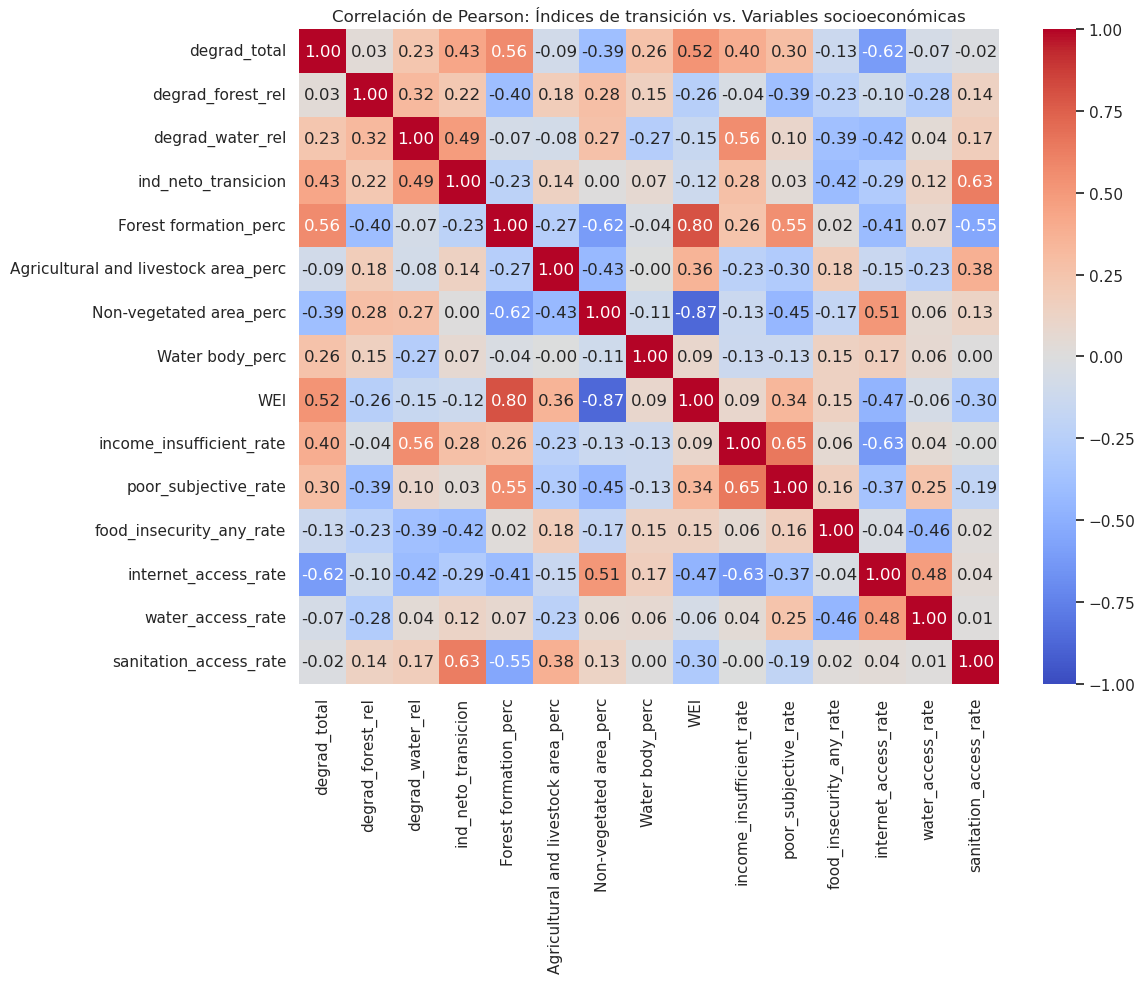

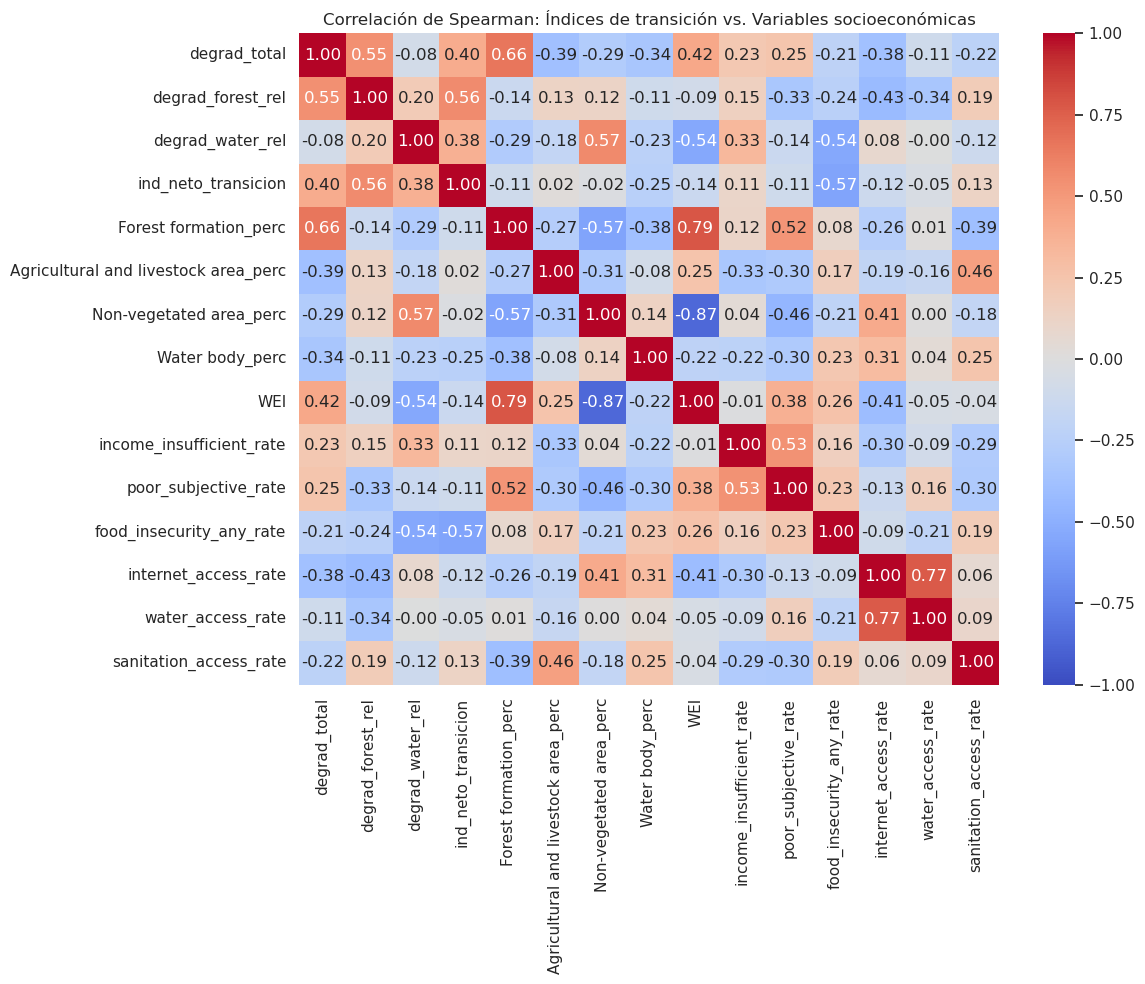

In [15]:
# Matriz de correlaciones entre X e Y seleccionadas
corr_cols = ['degrad_total', 'degrad_forest_rel', 'degrad_water_rel', 'ind_neto_transicion'] + classes_2021_perc + y_cols #'recover_agro_rel', 'ind_neto_transicion_rel'
corr_matrix = scatter_df[corr_cols].replace([np.inf, -np.inf], np.nan).corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación de Pearson: Índices de transición vs. Variables socioeconómicas')
plt.tight_layout()
plt.show()

spearman_corr = scatter_df[corr_cols].replace([np.inf, -np.inf], np.nan).corr(method='spearman')
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación de Spearman: Índices de transición vs. Variables socioeconómicas')
plt.tight_layout()
plt.show()


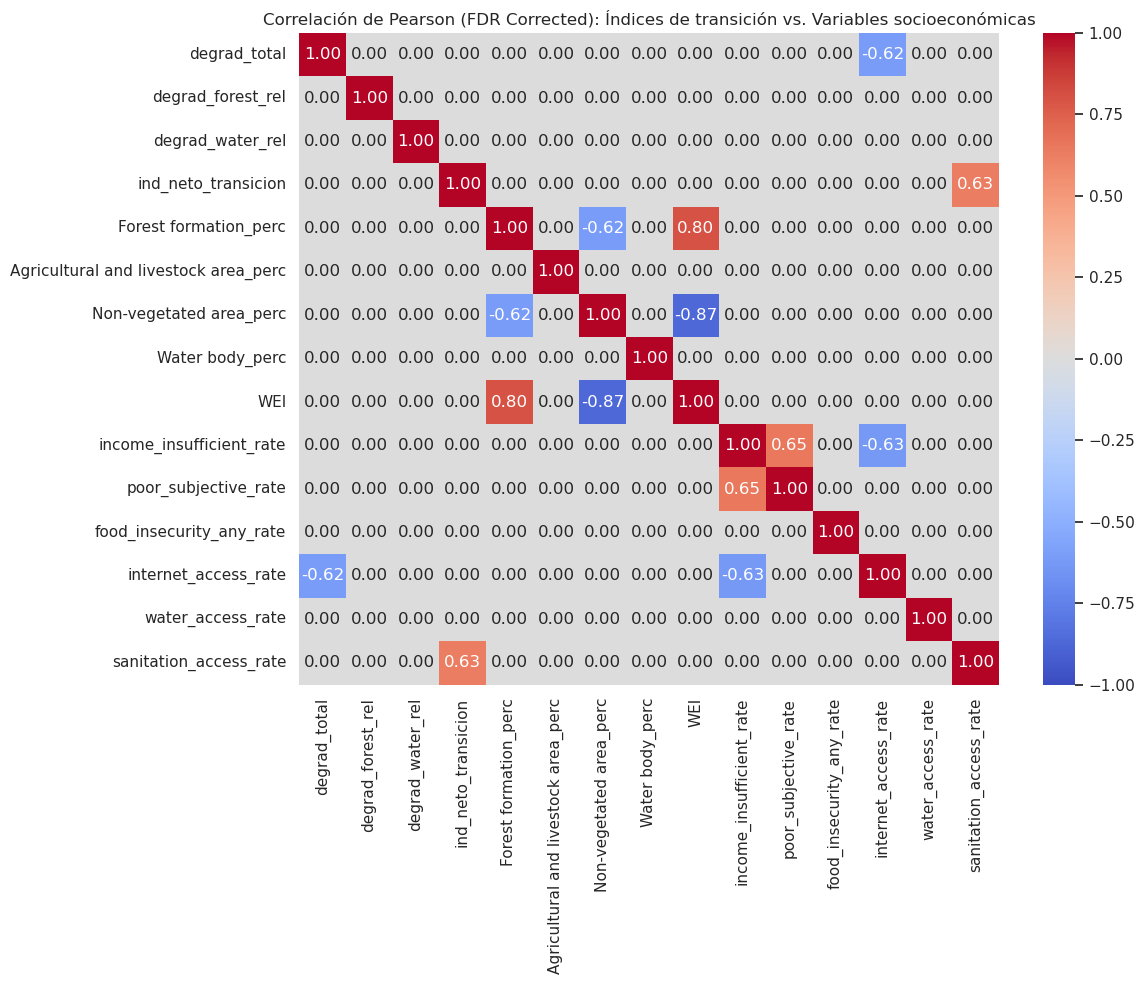

In [16]:
# 2. Calculate P-Value Matrix
n = scatter_df[corr_cols].shape[0]
p_matrix = np.zeros_like(corr_matrix)
for i in range(scatter_df[corr_cols].shape[1]):
    for j in range(scatter_df[corr_cols].shape[1]):
        if i != j:
            r, p = stats.pearsonr(scatter_df[corr_cols].iloc[:, i], scatter_df[corr_cols].iloc[:, j])
            p_matrix[i, j] = p

# 3. Apply FDR Correction
# Flatten p-values (excluding diagonal)
p_values = p_matrix[np.triu_indices_from(p_matrix, k=1)]
reject, p_corrected = fdrcorrection(p_values, alpha=0.05)

# Assign corrected p-values back to the upper triangle
p_matrix[np.triu_indices_from(p_matrix, k=1)] = p_corrected
# Mirror to lower triangle for a full matrix
p_matrix = p_matrix + p_matrix.T - np.diag(np.diag(p_matrix))

# 4. Create Significant Matrix
# Keep only correlations where corrected p-value < 0.05
significant_matrix = corr_matrix.where(p_matrix < 0.05, other=0)   

# 5. Visualize Significant Correlations
plt.figure(figsize=(12, 10))
sns.heatmap(significant_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación de Pearson (FDR Corrected): Índices de transición vs. Variables socioeconómicas')
plt.tight_layout()
plt.show()

## 4.5 Gráfico de Dispersión 2D

Generamos un grid de scatter plots para distintas combinaciones de variables del eje X (transición de suelo) y eje Y (socioeconómicas). Cada punto es un municipio, anotado con su nombre. Se añaden líneas de referencia en la media y una recta de tendencia OLS.


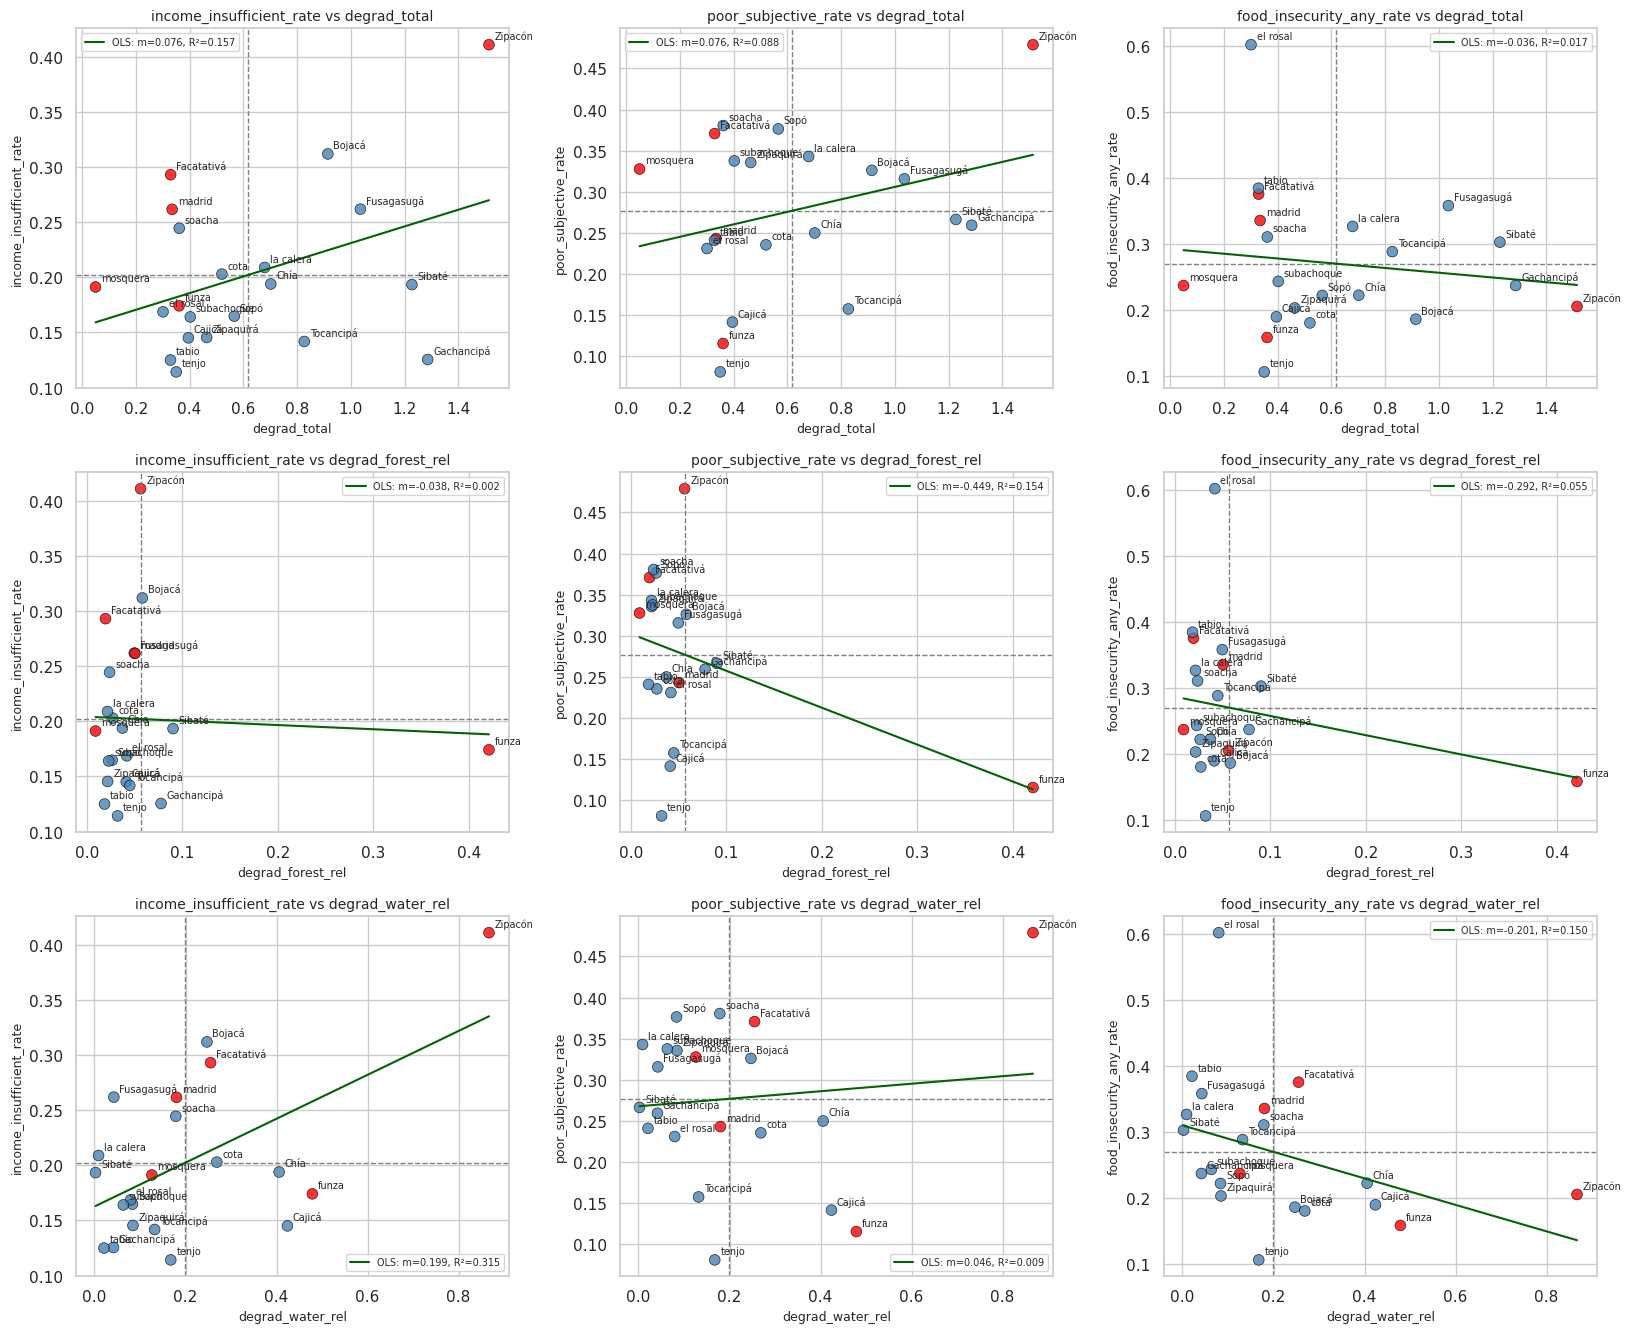

In [17]:
highlight_municipalities = {'funza', 'Facatativá', 'mosquera', 'madrid', 'Zipacón'}

def plot_scatter_grid(df, x_cols, y_cols, n_cols=3, figsize_per_subplot=(5, 4)):
    n_x = len(x_cols)
    n_y = len(y_cols)
    n_total = n_x * n_y
    n_rows = int(np.ceil(n_total / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_per_subplot[0] * n_cols, figsize_per_subplot[1] * n_rows))
    axes = np.atleast_2d(axes)

    for idx, (x_col, y_col) in enumerate([(x, y) for x in x_cols for y in y_cols]):
        r, c = divmod(idx, n_cols)
        ax = axes[r, c]
        sub = df[[x_col, y_col, 'municipio_base']].dropna()
        if sub.empty:
            ax.set_visible(False)
            continue
        x_mean = sub[x_col].mean()
        y_mean = sub[y_col].mean()

        colors = ['red' if m in highlight_municipalities else 'steelblue' for m in sub['municipio_base']]
        ax.scatter(sub[x_col], sub[y_col], c=colors, s=60, alpha=0.8, edgecolors='black', linewidth=0.5)

        for _, row in sub.iterrows():
            ax.annotate(row['municipio_base'], (row[x_col], row[y_col]), fontsize=7, textcoords='offset points', xytext=(4, 4))

        ax.axvline(x_mean, color='gray', linestyle='--', linewidth=1)
        ax.axhline(y_mean, color='gray', linestyle='--', linewidth=1)

        valid = sub[[x_col, y_col]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) > 2:
            slope, intercept, r_value, p_value, std_err = stats.linregress(valid[x_col], valid[y_col])
            x_line = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
            ax.plot(x_line, slope * x_line + intercept, color='darkgreen', linestyle='-', linewidth=1.5, label=f'OLS: m={slope:.3f}, R\u00b2={r_value**2:.3f}')
            ax.legend(fontsize=7, loc='best')

        ax.set_xlabel(x_col, fontsize=9)
        ax.set_ylabel(y_col, fontsize=9)
        ax.set_title(f'{y_col} vs {x_col}', fontsize=10)

    for idx in range(n_total, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].set_visible(False)

    plt.tight_layout()
    return fig

sel_x = ['degrad_total', 'degrad_forest_rel', 'degrad_water_rel']
sel_y = ['income_insufficient_rate', 'poor_subjective_rate', 'food_insecurity_any_rate']

# Grid principal: variable X por defecto (degrad_total) vs varias Y
fig1 = plot_scatter_grid(scatter_df, sel_x, sel_y, n_cols=3, figsize_per_subplot=(5.5, 4.5))
plt.show()


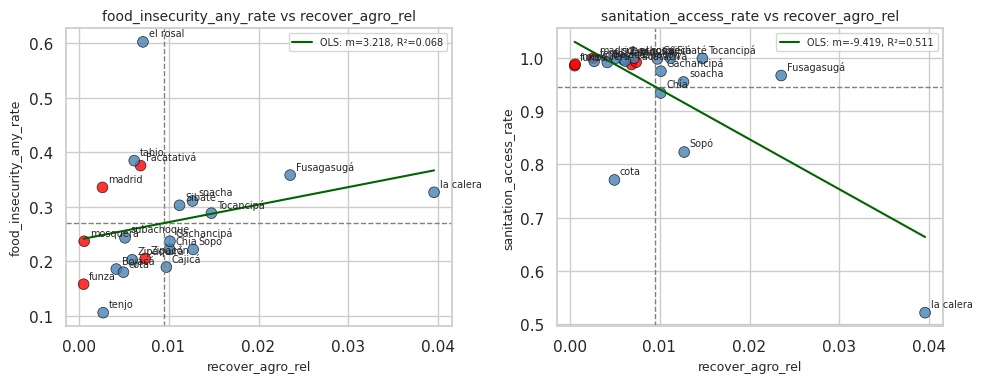

In [18]:
# Grid para ind_neto_transicion vs varias Y
fig2 = plot_scatter_grid(scatter_df, ['recover_agro_rel'], ['food_insecurity_any_rate', 'sanitation_access_rate'], 
                         n_cols=2, figsize_per_subplot=(5, 4))
plt.show()


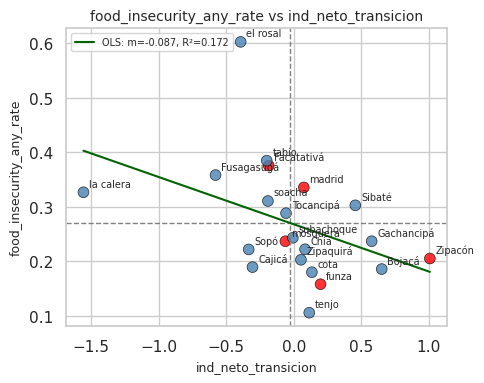

In [19]:
# Grid para ind_neto_transicion vs food_insecurity_any_rate
fig3 = plot_scatter_grid(scatter_df, ['ind_neto_transicion'], ['food_insecurity_any_rate'], n_cols=1, figsize_per_subplot=(5, 4))
plt.show()

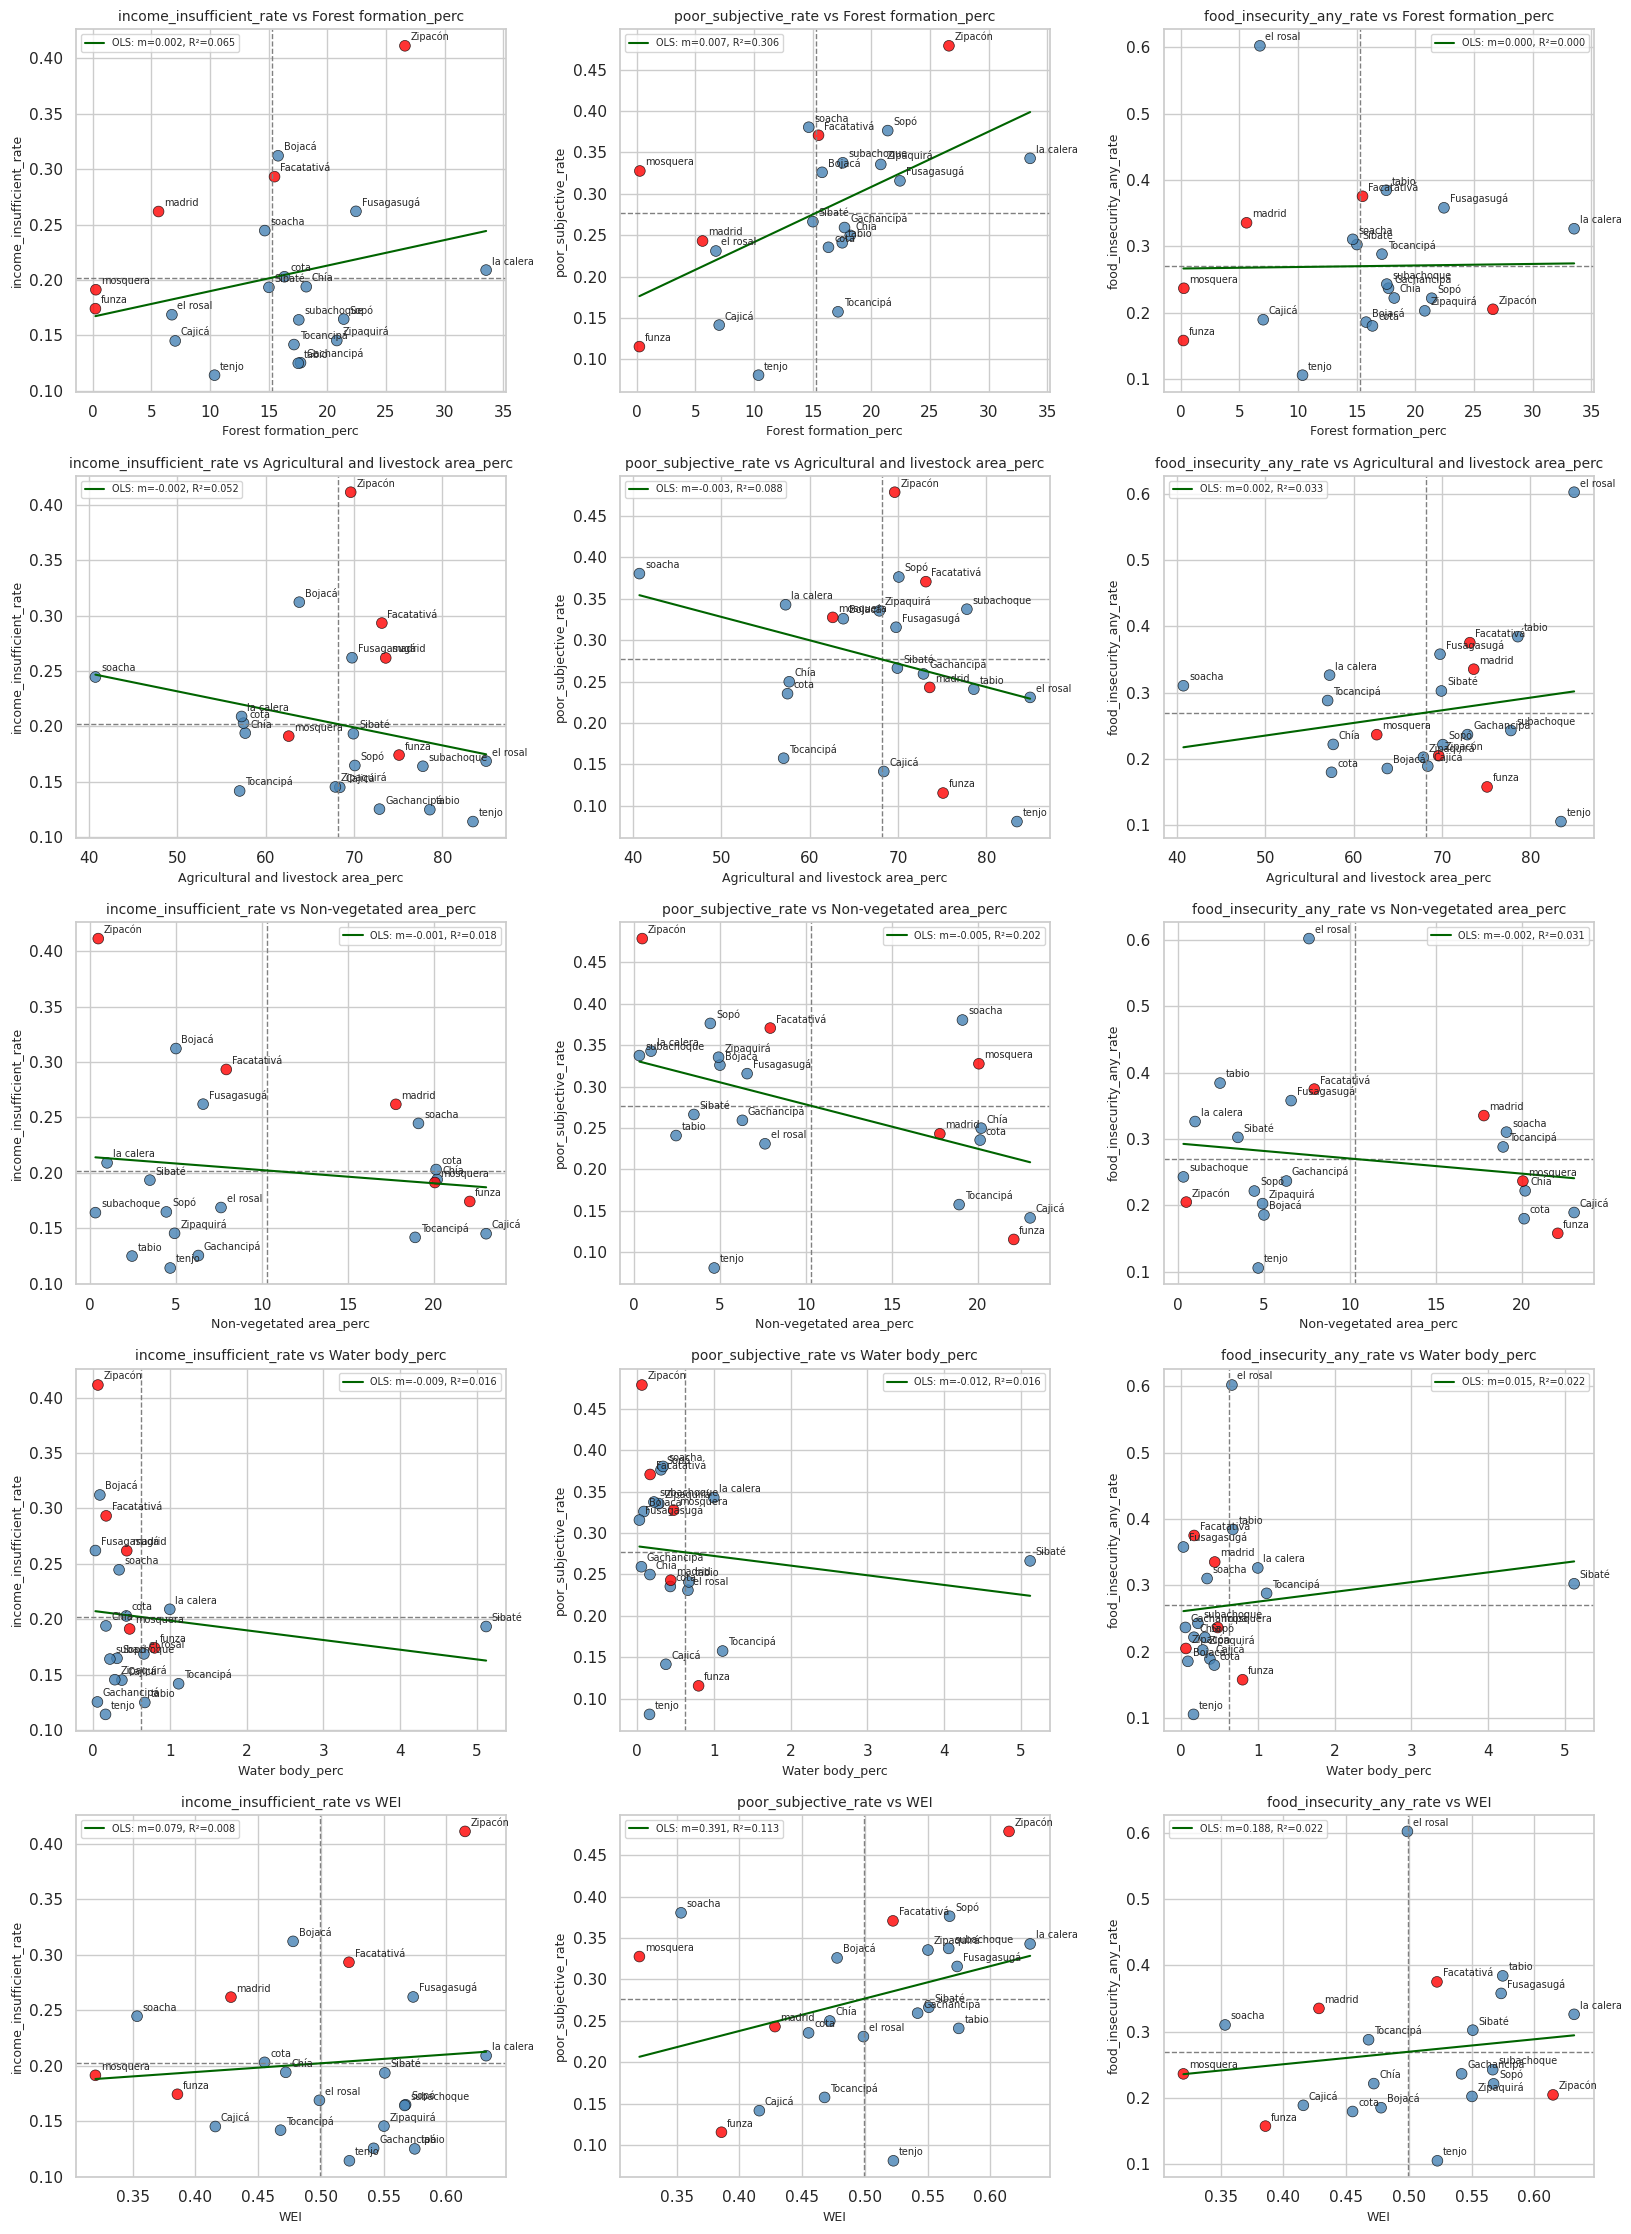

In [20]:
sel_x = ['Forest formation_perc', 'Agricultural and livestock area_perc', 'Non-vegetated area_perc', 'Water body_perc', 'WEI']

# Grid principal: variable X por defecto (degrad_total) vs varias Y
fig4 = plot_scatter_grid(scatter_df, sel_x, sel_y, n_cols=3, figsize_per_subplot=(5.5, 4.5))
plt.show()

## 4.6 Análisis Adicional (Sensibilidad y Descomposición)

- **Sensibilidad del eje X:** repetimos el scatter usando `ind_neto_transicion_rel`.
- **Descomposición:** graficamos por separado `degrad_total` y `recover_total` para ver qué mecanismo domina.
- **Roles mixtos:** identificamos municipios con balance neutro pero alta pobreza.


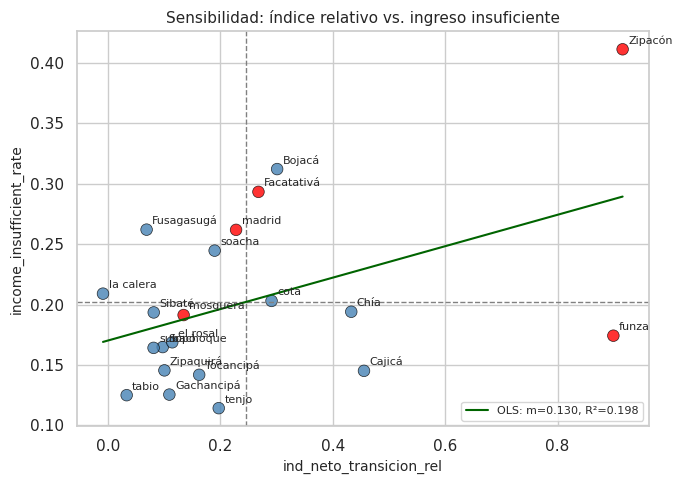

In [21]:
# Sensibilidad: ind_neto_transicion_rel vs income_insufficient_rate
fig, ax = plt.subplots(figsize=(7, 5))
sub = scatter_df[['ind_neto_transicion_rel', 'income_insufficient_rate', 'municipio_base']].dropna()
colors = ['red' if m in highlight_municipalities else 'steelblue' for m in sub['municipio_base']]
ax.scatter(sub['ind_neto_transicion_rel'], sub['income_insufficient_rate'], c=colors, s=70, alpha=0.8, edgecolors='black', linewidth=0.5)
for _, row in sub.iterrows():
    ax.annotate(row['municipio_base'], (row['ind_neto_transicion_rel'], row['income_insufficient_rate']), fontsize=8, textcoords='offset points', xytext=(4, 4))
ax.axvline(sub['ind_neto_transicion_rel'].mean(), color='gray', linestyle='--', linewidth=1)
ax.axhline(sub['income_insufficient_rate'].mean(), color='gray', linestyle='--', linewidth=1)
valid = sub[['ind_neto_transicion_rel', 'income_insufficient_rate']].replace([np.inf, -np.inf], np.nan).dropna()
if len(valid) > 2:
    slope, intercept, r_value, p_value, std_err = stats.linregress(valid['ind_neto_transicion_rel'], valid['income_insufficient_rate'])
    x_line = np.linspace(valid['ind_neto_transicion_rel'].min(), valid['ind_neto_transicion_rel'].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='darkgreen', linestyle='-', linewidth=1.5, label=f'OLS: m={slope:.3f}, R²={r_value**2:.3f}')
    ax.legend(fontsize=8)
ax.set_xlabel('ind_neto_transicion_rel', fontsize=10)
ax.set_ylabel('income_insufficient_rate', fontsize=10)
ax.set_title('Sensibilidad: índice relativo vs. ingreso insuficiente', fontsize=11)
plt.tight_layout()
plt.show()


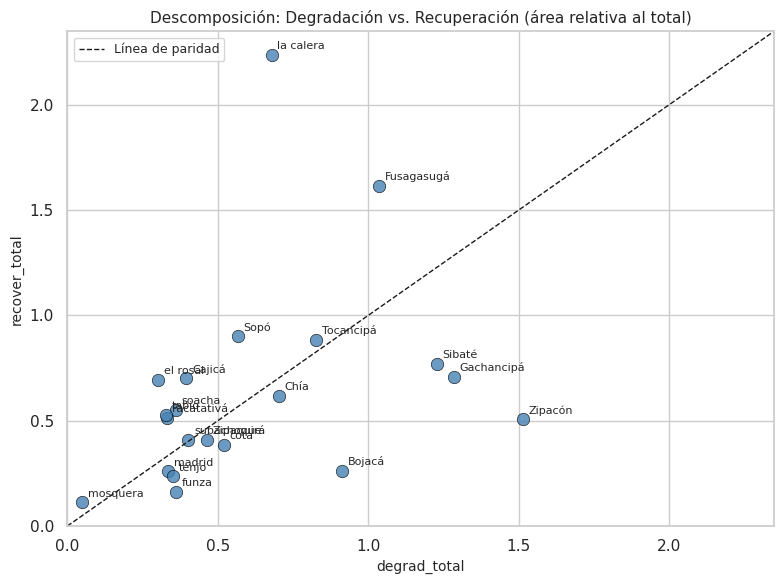

Municipios con balance neutro y alta pobreza (ingreso insuficiente):
   municipio_base  ind_neto_transicion  income_insufficient_rate
3      Facatativá            -0.185453                  0.293271
15         madrid             0.074499                  0.261822
17         soacha            -0.191172                  0.244608
11           cota             0.134252                  0.202999
2            Chía             0.083600                  0.194012


In [22]:
# Descomposición: degrad_total vs recover_total por municipio
fig, ax = plt.subplots(figsize=(8, 6))
sub = scatter_df[['municipio_base', 'degrad_total', 'recover_total']].dropna()
ax.scatter(sub['degrad_total'], sub['recover_total'], c='steelblue', s=80, alpha=0.8, edgecolors='black', linewidth=0.5)
for _, row in sub.iterrows():
    ax.annotate(row['municipio_base'], (row['degrad_total'], row['recover_total']), fontsize=8, textcoords='offset points', xytext=(4, 4))
lims = [0, max(sub['degrad_total'].max(), sub['recover_total'].max()) * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1, label='Línea de paridad')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('degrad_total', fontsize=10)
ax.set_ylabel('recover_total', fontsize=10)
ax.set_title('Descomposición: Degradación vs. Recuperación (área relativa al total)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Identificar roles mixtos: ind_neto_transicion cercano a 0 pero alta pobreza
scatter_df['pobreza_alta'] = scatter_df['income_insufficient_rate'] > scatter_df['income_insufficient_rate'].median()
scatter_df['balance_neutro'] = scatter_df['ind_neto_transicion'].abs() < scatter_df['ind_neto_transicion'].abs().median()
mixtos = scatter_df[scatter_df['pobreza_alta'] & scatter_df['balance_neutro']][['municipio_base', 'ind_neto_transicion', 'income_insufficient_rate']]
print('Municipios con balance neutro y alta pobreza (ingreso insuficiente):')
print(mixtos.sort_values('income_insufficient_rate', ascending=False))


## Resultados y Próximos Pasos

- El DataFrame `scatter_df` contiene los 21 municipios con sus índices de transición y tasas socioeconómicas.
- Los gráficos anteriores exploran la asociación entre degradación/recuperación del suelo y pobreza/vulnerabilidad.
- Las correlaciones de Pearson y Spearman permiten evaluar la robustez de la relación.
- **Nota:** Esta es una asociación ecológica a nivel municipal; no implica causalidad.


In [23]:
# Exportar tabla consolidada (opcional, para inspección rápida)
scatter_df[['municipio_base'] + x_cols + y_cols].round(6)

,municipio_base,degrad_total,degrad_forest_rel,degrad_water_rel,recover_agro_rel,ind_neto_transicion,ind_neto_transicion_rel,Forest formation_perc,Agricultural and livestock area_perc,Non-vegetated area_perc,Water body_perc,WEI,income_insufficient_rate,poor_subjective_rate,food_insecurity_any_rate,internet_access_rate,water_access_rate,sanitation_access_rate
0,Bojacá,0.914479,0.058210,0.247063,0.004198,0.651456,0.301075,15.798934,63.801663,5.014019,0.087960,0.477877,0.312127,0.326021,0.185540,0.538103,0.857349,0.991802
1,Cajicá,0.395751,0.041414,0.423920,0.009758,-0.305487,0.455576,7.022707,68.386566,23.023361,0.374924,0.415909,0.145110,0.141558,0.189132,0.795820,0.953647,0.998487
2,Chía,0.702183,0.037363,0.405670,0.010125,0.083600,0.432908,18.199532,57.676961,20.180236,0.167185,0.472052,0.194012,0.249899,0.221885,0.744031,0.893684,0.934364
3,Facatativá,0.329755,0.019677,0.255061,0.006889,-0.185453,0.267849,15.494946,73.154694,7.937041,0.169677,0.522420,0.293271,0.370756,0.375271,0.656258,0.785959,0.987942
4,Fusagasugá,1.035554,0.049821,0.042553,0.023519,-0.579001,0.068854,22.440663,69.776041,6.593024,0.029916,0.573586,0.261989,0.315716,0.357895,0.602637,0.840933,0.967199
5,Gachancipá,1.285963,0.077822,0.041665,0.010153,0.576863,0.109335,17.710831,72.882848,6.317893,0.056003,0.542083,0.125449,0.259344,0.236634,0.626072,0.762926,0.975293
6,Sibaté,1.227253,0.090374,0.002400,0.011219,0.455842,0.081555,15.015086,69.928743,3.502550,5.120409,0.550999,0.193458,0.266395,0.302463,0.710335,0.908923,1.000000
7,Sopó,0.566521,0.026673,0.083574,0.012740,-0.333793,0.097508,21.397320,70.094093,4.456428,0.311317,0.567557,0.164791,0.376389,0.221553,0.680066,0.922055,0.823335
8,Tocancipá,0.826953,0.045075,0.132099,0.014764,-0.057176,0.162410,17.154666,57.044091,18.902173,1.113946,0.467907,0.141820,0.157580,0.288031,0.652034,0.719604,0.999414
9,Zipacón,1.514010,0.056402,0.866668,0.007405,1.007704,0.915665,26.618154,69.625765,0.504662,0.062467,0.614935,0.411304,0.478792,0.204897,0.372786,0.847292,0.992278


# Próximos pasos

Variables disponibles en 2014 y 2017. Buscarlos en 2021.
* Pobreza monetaria según municipio
* Hogares con deficit de vivienda según municipio
* Hogares por tipo de vivienda según municipio